In [1]:
print(8)

8


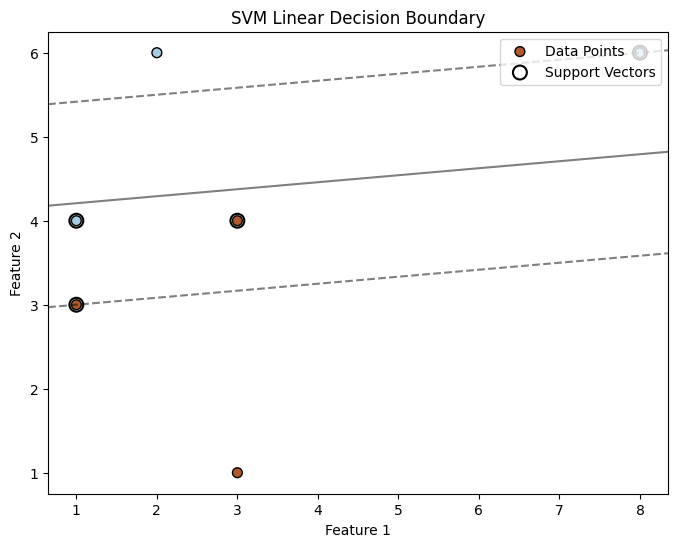

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# 1. Your Data
x = [[3,1],[1,4],[2,6],[8,6],[1,3],[3,4]]
y = [1,0,0,0,1,1]

# Convert to numpy arrays for easier plotting handling
X = np.array(x)
Y = np.array(y)

# 2. Fit the Model
clf = svm.SVC(kernel="linear", C=1.0)
clf.fit(X, Y)

# 3. Visualization Logic
plt.figure(figsize=(8, 6))

# Plot the actual data points
# c=Y colors them by class, cmap separates them visually
plt.scatter(X[:, 0], X[:, 1], c=Y, s=50, cmap=plt.cm.Paired, edgecolors='k', label='Data Points')

# Get the current axes to plot the decision boundary lines
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid to evaluate the model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get the decision function (distance to the separating hyperplane)
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
# Level 0 is the decision boundary
# Level -1 and 1 are the margins (passing through support vectors)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Highlight the support vectors (the points that define the boundary)
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
           linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title('SVM Linear Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.show()